In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../Datasets/Bank.csv")

In [3]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44.0,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53.0,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28.0,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39.0,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55.0,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,59.0,retired,married,high.school,unknown,no,yes,telephone,jun,thu,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,0
41184,31.0,housemaid,married,basic.4y,unknown,no,no,telephone,may,thu,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0
41185,42.0,admin.,single,university.degree,unknown,yes,yes,telephone,may,wed,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
41186,48.0,technician,married,professional.course,no,no,yes,telephone,oct,tue,...,2,999,0,nonexistent,-3.4,92.431,-26.9,0.742,5017.5,0


# Data Preparation:

### Checking For Any Missing Values:

In [4]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64

### Checking Datatype Of The Columns:

In [5]:
df.dtypes

age               float64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp_var_rate      float64
cons_price_idx    float64
cons_conf_idx     float64
euribor3m         float64
nr_employed       float64
y                   int64
dtype: object

In [6]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44.0,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53.0,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28.0,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39.0,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55.0,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,59.0,retired,married,high.school,unknown,no,yes,telephone,jun,thu,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,0
41184,31.0,housemaid,married,basic.4y,unknown,no,no,telephone,may,thu,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0
41185,42.0,admin.,single,university.degree,unknown,yes,yes,telephone,may,wed,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
41186,48.0,technician,married,professional.course,no,no,yes,telephone,oct,tue,...,2,999,0,nonexistent,-3.4,92.431,-26.9,0.742,5017.5,0


#  Exploratory Data Analysis (EDA):

###  What is the distribution of key features (age, job, marital status, etc.)

In [7]:
df.describe()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.024082,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.421222,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [8]:
df.job.value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [9]:
df.education.value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [10]:
df.marital.value_counts()

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

In [11]:
df.default.value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [12]:
df.housing.value_counts()

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

In [13]:
df.loan.value_counts()

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

In [14]:
df.contact.value_counts()

contact
cellular     26144
telephone    15044
Name: count, dtype: int64

In [15]:
df.month.value_counts()

month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64

In [16]:
df.day_of_week.value_counts()

day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64

### Which customer profiles (job, education, etc.) have higher subscription rates?

In [17]:
jb = df.groupby('job')['y'].value_counts(normalize=True).unstack()
jb

y,0,1
job,,
admin.,0.870274,0.129726
blue-collar,0.931057,0.068943
entrepreneur,0.914835,0.085165
housemaid,0.900000,0.100000
management,0.887825,0.112175
retired,0.747674,0.252326
self-employed,0.895144,0.104856
services,0.918619,0.081381
student,0.685714,0.314286


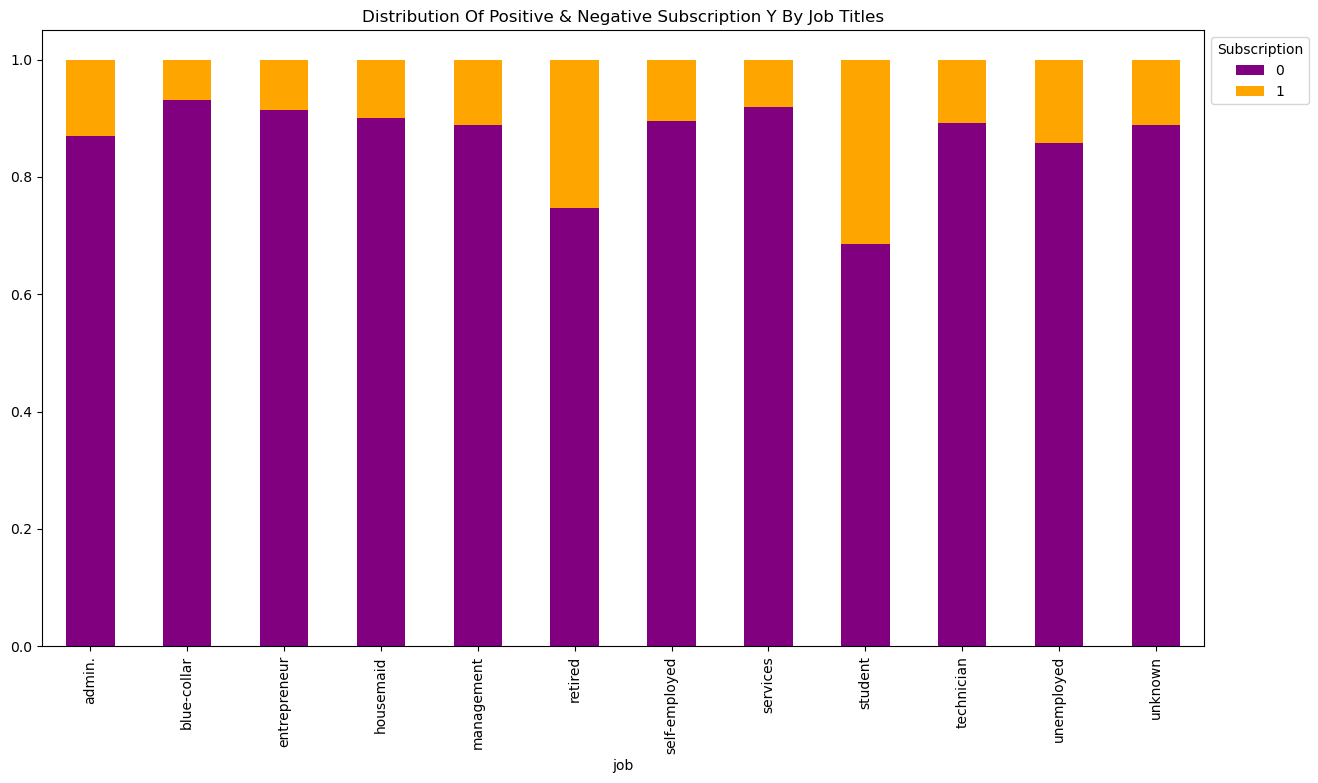

In [72]:
jb.plot(kind='bar',stacked=True, figsize=[15,8], color=['purple', 'orange'])
plt.title("Distribution Of Positive & Negative Subscription Y By Job Titles")
plt.legend(title='Subscription', bbox_to_anchor=(1.0,1.0))
plt.show()

### Students have the highest subscription rate i.e. the likelihood of students subscribing to the bank’s service is higher than for any other job category, followed by retired i.e senior citizens.

### The remaining job categories, such as housemaid, self-employed, technician, etc., have a moderate subscription rate.

### Blue-collar professions exhibit the lowest subscription rate.

In [19]:
ed = df.groupby('education')['y'].value_counts(normalize=True).unstack()
ed

y,0,1
education,,
basic.4y,0.897510,0.102490
basic.6y,0.917976,0.082024
basic.9y,0.921754,0.078246
high.school,0.891645,0.108355
illiterate,0.777778,0.222222
professional.course,0.886515,0.113485
university.degree,0.862755,0.137245
unknown,0.854997,0.145003


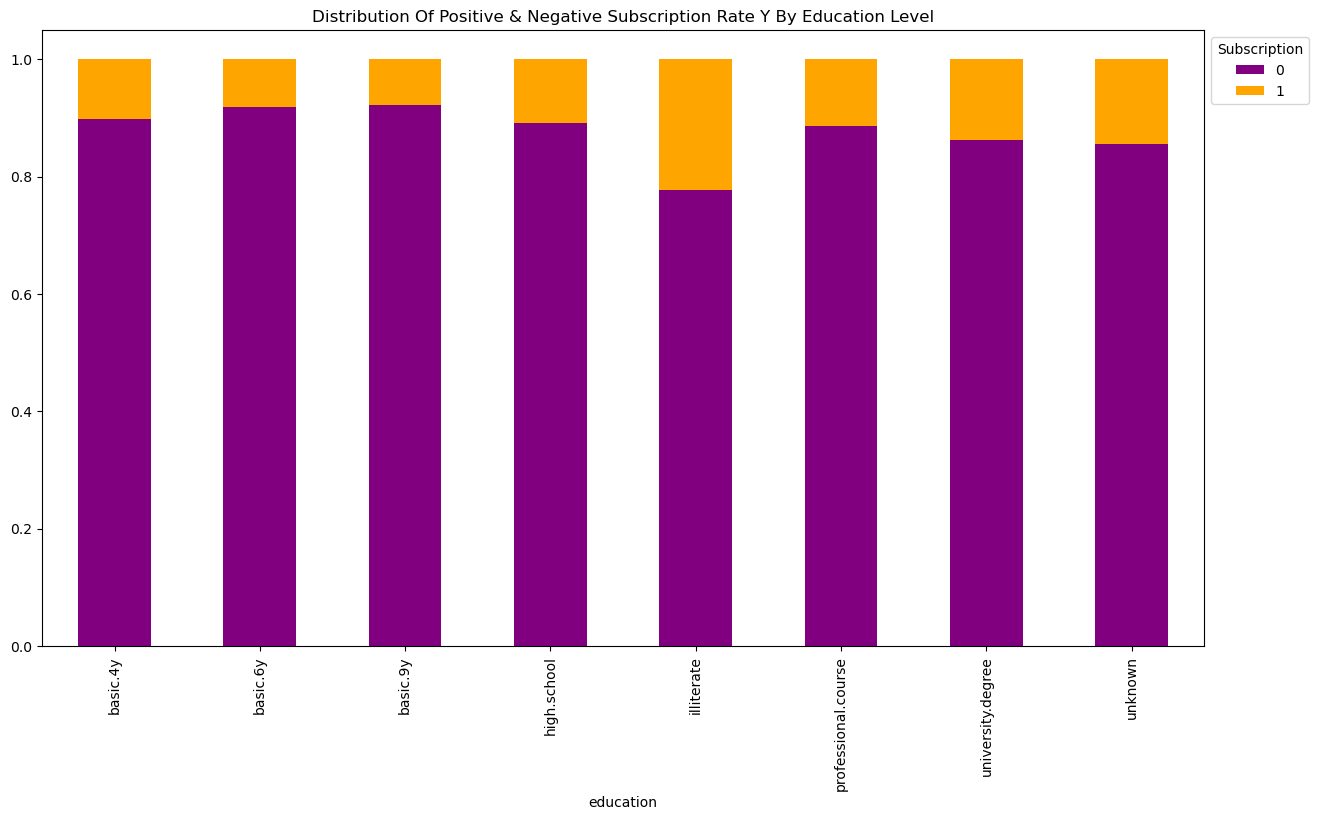

In [73]:
ed.plot(kind='bar',stacked=True, figsize=[15,8], color=['purple', 'orange'])
plt.title("Distribution Of Positive & Negative Subscription Rate Y By Education Level")
plt.legend(title='Subscription', bbox_to_anchor=(1.0,1.0))
plt.show()

### In terms of education level, the highest proportion of positive subscription responses (“yes”) is among illiterate individuals followed by 'Unknown'. 

### The lowest proportion of positive subscription responses are among basic.9yrs group.

### The highest proportion of negative subscription responses ("no") is among basic.9yrs followed by basic.6yrs individuals.

### The lowest proportion of negative subscription responses are among the group of illiterate individuals.

In [21]:
m = df.groupby('marital')['y'].value_counts(normalize=True).unstack()
m

y,0,1
marital,,
divorced,0.896791,0.103209
married,0.898427,0.101573
single,0.859959,0.140041
unknown,0.850000,0.150000


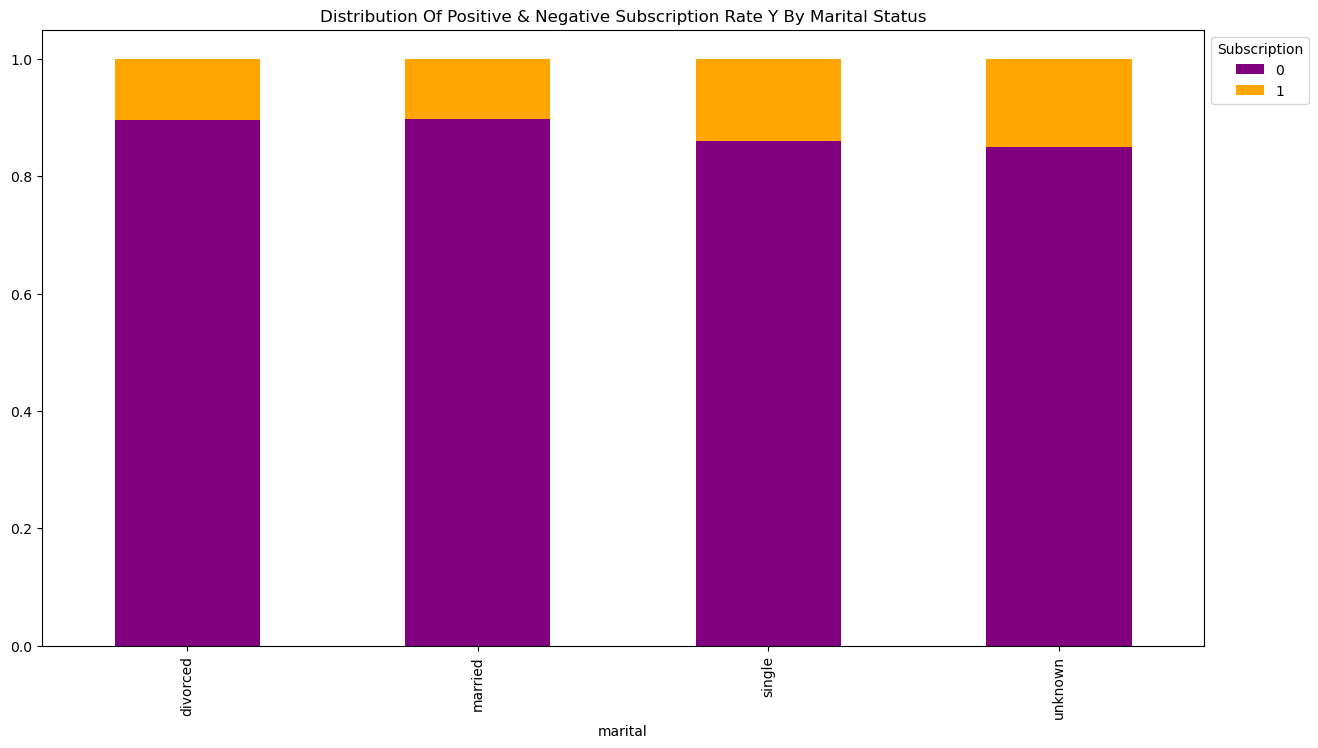

In [74]:
m.plot(kind='bar',stacked=True, figsize=[15,8], color=['purple', 'orange'])
plt.title("Distribution Of Positive & Negative Subscription Rate Y By Marital Status")
plt.legend(title='Subscription', bbox_to_anchor=(1.0,1.0))
plt.show()

### The group with an unknown marital status shows the highest proportion of positive subscription responses; that is, they use the bank’s services more frequently than other groups.

### The group with the divorced marital status shows the highest proportion of negative responses; that is, they make the lowest use of the bank's services as compared to other groups.

### What are the relationships between input features and the target variable?

In [23]:
p = df[['age', 'campaign','pdays','emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'y']].corr()

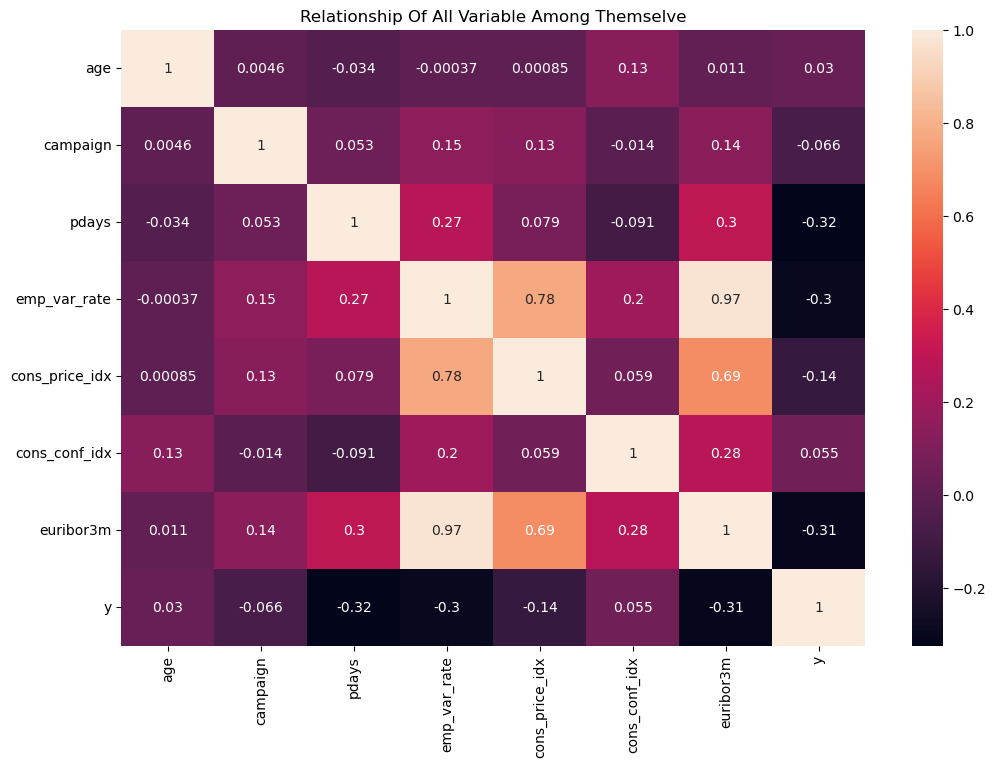

In [75]:
plt.figure(figsize=[12,8])
plt.title("Relationship Of All Variable Among Themselve")
sb.heatmap(p, annot=True)
plt.show()

### The correlation analysis indicates that the subscription rate does not show any strong or consistent relationship with the other variables, suggesting that factors influencing subscriptions may be more complex or non-linear.

# Client Profile Analysis:

###  How do job, marital status, and education affect subscription decisions?

In [25]:
j = df.groupby('job')['y'].value_counts(normalize=True).unstack() * 100
j

y,0,1
job,,
admin.,87.027442,12.972558
blue-collar,93.105684,6.894316
entrepreneur,91.483516,8.516484
housemaid,90.000000,10.000000
management,88.782490,11.217510
retired,74.767442,25.232558
self-employed,89.514426,10.485574
services,91.861930,8.138070
student,68.571429,31.428571


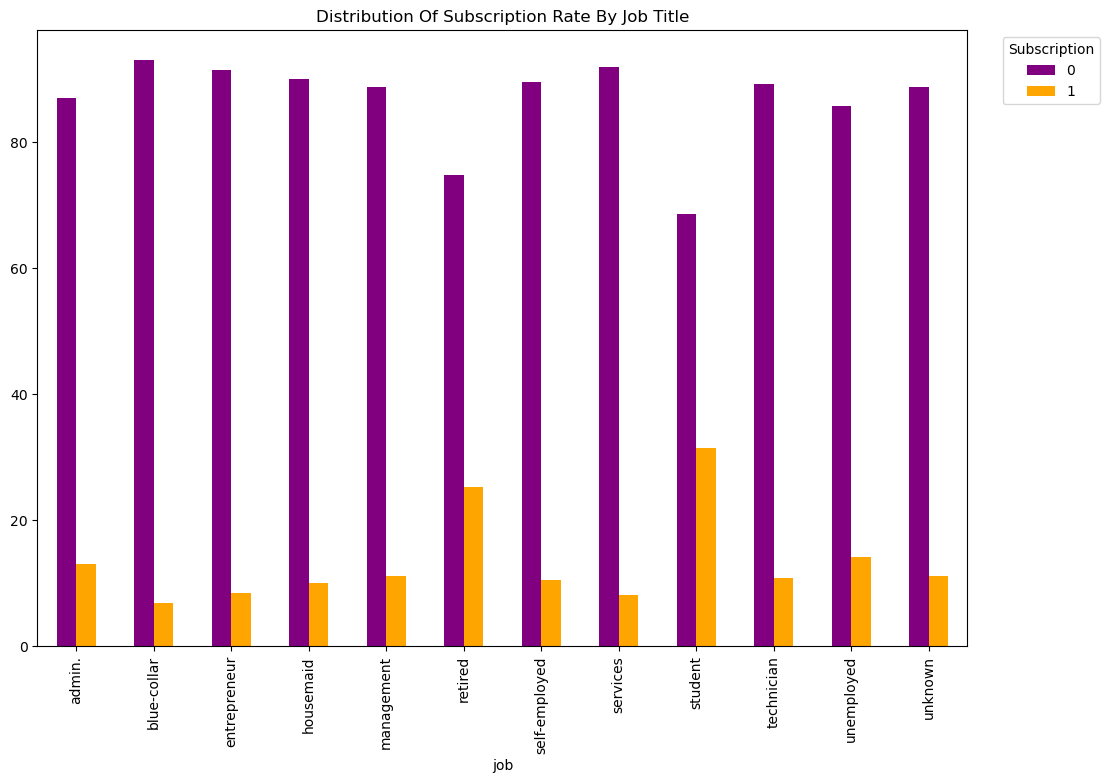

In [76]:
j.plot(kind='bar', figsize=[12,8], color=['purple', 'orange'])
plt.title("Distribution Of Subscription Rate By Job Title")
plt.legend(title='Subscription', bbox_to_anchor=(1.15,1.0))
plt.show()

### Students are the group which make the most use of bank's services hence the higher positive susbcription responses.
### The blue-collar job group has the highest proportion of negative subscription responses; that is, they make less use of the bank’s services compared to other groups and therefore exhibit the highest negative subscription rate.

In [27]:
e = df.groupby('education')['y'].value_counts(normalize=True).unstack() * 100
e

y,0,1
education,,
basic.4y,89.750958,10.249042
basic.6y,91.797557,8.202443
basic.9y,92.175352,7.824648
high.school,89.164477,10.835523
illiterate,77.777778,22.222222
professional.course,88.651535,11.348465
university.degree,86.275477,13.724523
unknown,85.499711,14.500289


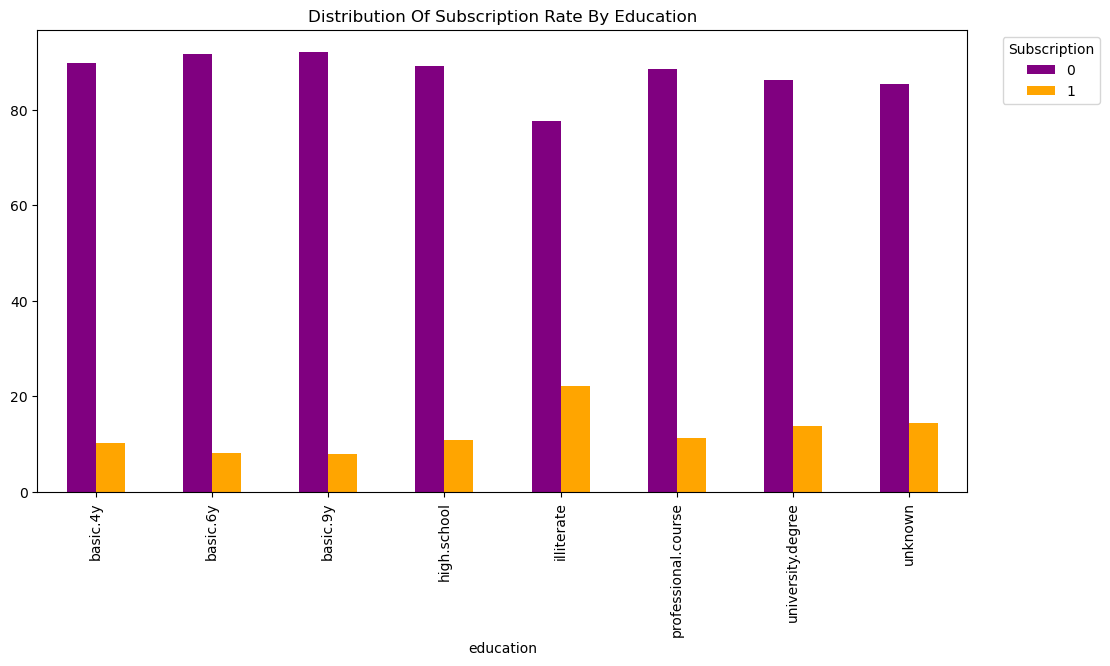

In [77]:
e.plot(kind='bar', figsize=[12,6], color=['purple', 'orange'])
plt.title("Distribution Of Subscription Rate By Education")
plt.legend(title='Subscription', bbox_to_anchor=(1.15,1.0))
plt.show()

In [29]:
md = df.groupby('marital')['y'].value_counts(normalize=True).unstack() * 100
md

y,0,1
marital,,
divorced,89.679098,10.320902
married,89.842747,10.157253
single,85.995851,14.004149
unknown,85.000000,15.000000


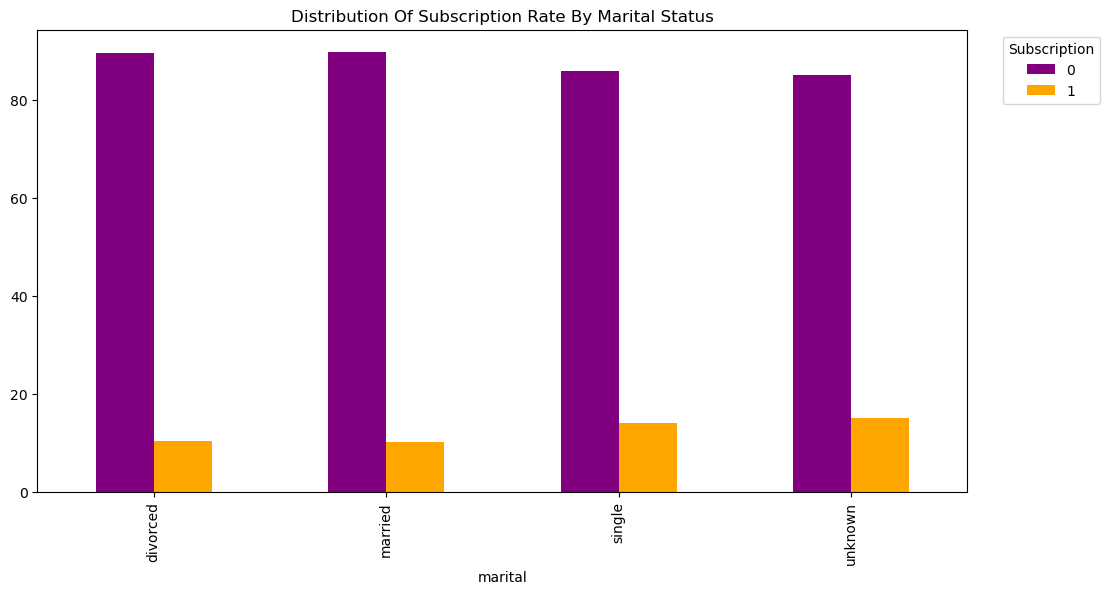

In [78]:
md.plot(kind='bar', figsize=[12,6], color=['purple', 'orange'])
plt.title("Distribution Of Subscription Rate By Marital Status")
plt.legend(title='Subscription', bbox_to_anchor=(1.15,1.0))
plt.show()

#  Campaign Effectiveness:

###  Does the duration of the call increase the chances of a successful subscription?

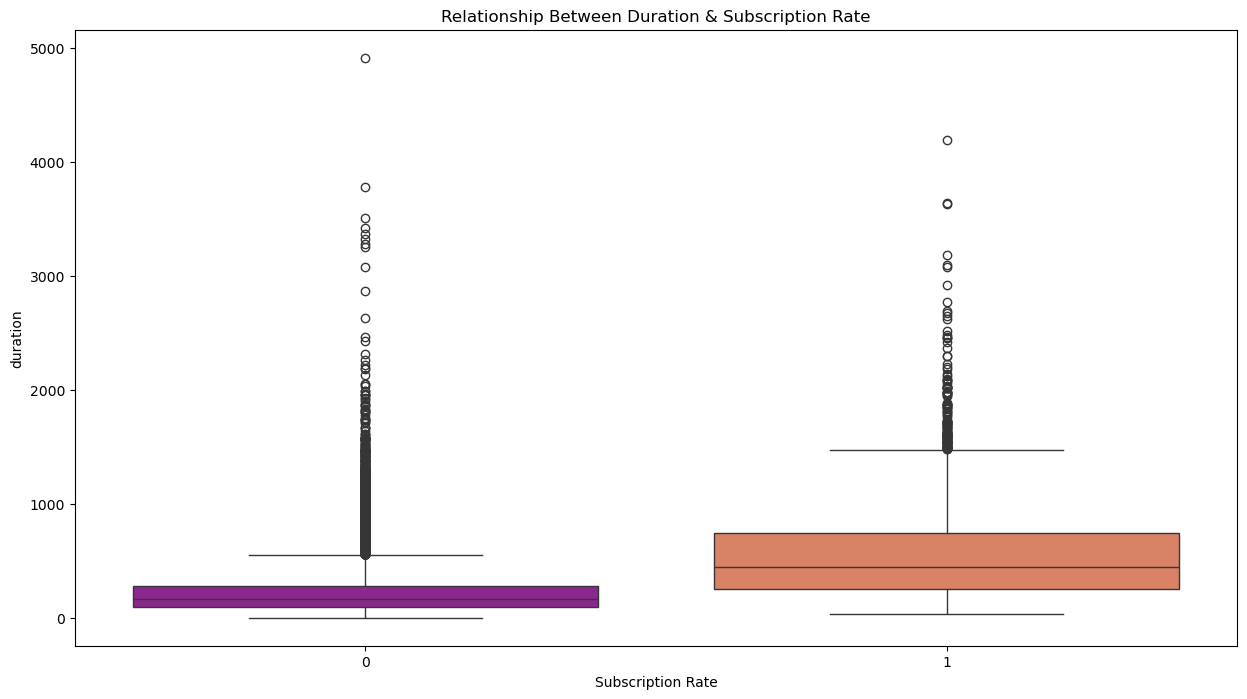

In [31]:
plt.figure(figsize=[15,8])
sb.boxplot(x=df.y, y=df.duration, palette='plasma')
plt.title("Relationship Between Duration & Subscription Rate")
plt.xlabel("Subscription Rate")
plt.show()

### The graph clearly illustrates that longer contact durations are associated with a higher likelihood of subscription, as customers in group 1 exhibit significantly higher call durations than those in group 0.

In [32]:
dy = df.groupby('y')['duration'].mean()
dy

y
0    220.844807
1    553.191164
Name: duration, dtype: float64

###  Which contact methods (e.g., telephone, cellular) are most effective?

In [33]:
cm = df.groupby('contact')['y'].value_counts(normalize=True).unstack() * 100
cm

y,0,1
contact,,
cellular,85.262393,14.737607
telephone,94.768679,5.231321


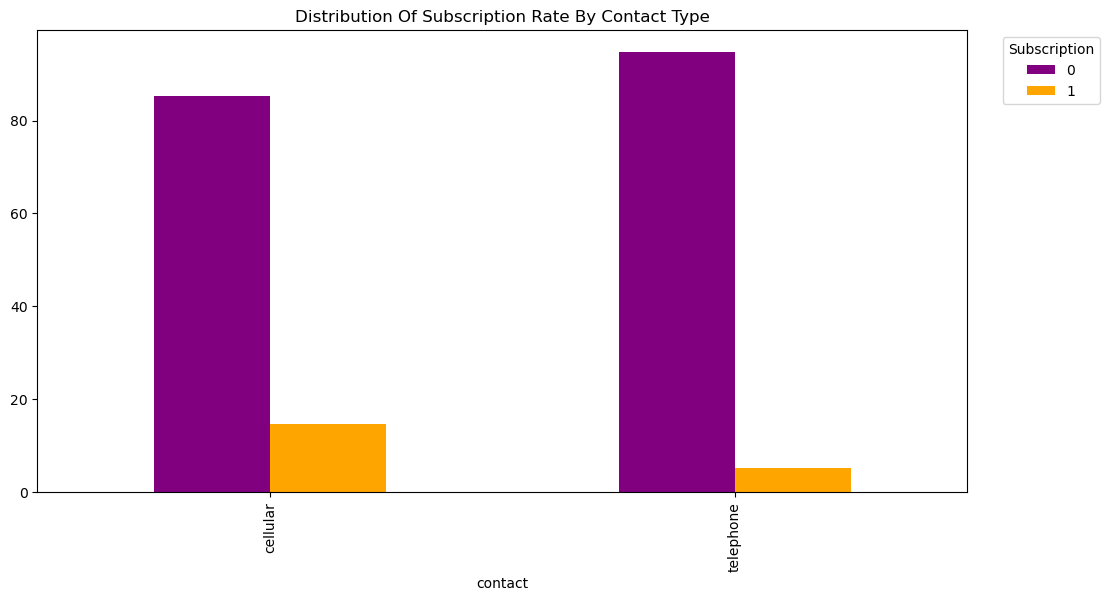

In [79]:
cm.plot(kind='bar', figsize=[12,6], color=['purple', 'orange'])
plt.title("Distribution Of Subscription Rate By Contact Type")
plt.legend(title='Subscription', bbox_to_anchor=(1.15,1.0))
plt.show()

### In terms of contact type, the majority of cellular contacts correspond to non-subscribers, indicating a high rate of negative subscription responses. 
### Only about 15% of cellular contacts result in successful subscriptions, highlighting a relatively low conversion rate for this contact method.

### The telephone contact method exhibits a lower subscription conversion rate compared to cellular contacts, with just around 5–6% of contacts resulting in subscriptions. Most telephone contacts correspond to non-subscribers, highlighting its limited effectiveness.

### How many contacts are usually needed before a client subscribes?

In [35]:
g = df.groupby('y')['campaign'].mean()
g

y
0    2.633085
1    2.051724
Name: campaign, dtype: float64

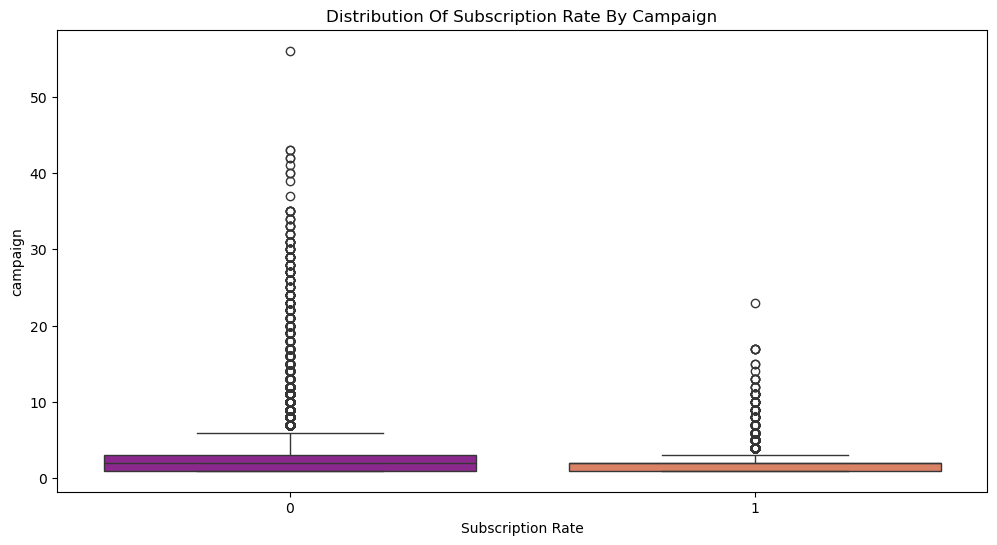

In [36]:
plt.figure(figsize=[12,6])
sb.boxplot(x=df.y, y=df.campaign, palette='plasma')
plt.title("Distribution Of Subscription Rate By Campaign")
plt.xlabel("Subscription Rate")
plt.show()

### This graph shows the average distribution of the subscription rate based on the number of contacts made to the same client during the current campaign. 
### It reveals that the majority of clients were not converted, while conversions mainly occurred when the number of contacts ranged between 5 and 20.

# Previous Campaign Impact:

### How does the outcome of previous campaigns influence the current one?

In [37]:
pre = df.groupby('poutcome')['y'].value_counts(normalize=True).unstack() * 100
pre

y,0,1
poutcome,,
failure,85.771402,14.228598
nonexistent,91.167787,8.832213
success,34.887109,65.112891


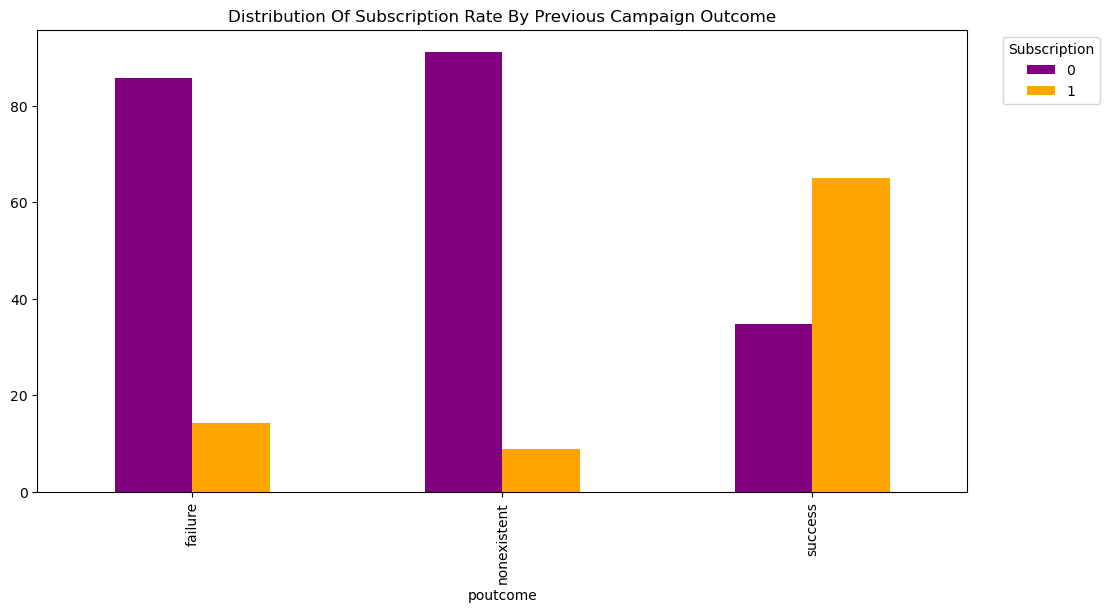

In [80]:
pre.plot(kind='bar', figsize=[12,6], color=['purple', 'orange'])
plt.title("Distribution Of Subscription Rate By Previous Campaign Outcome")
plt.legend(title='Subscription', bbox_to_anchor=(1.15,1.0))
plt.show()

### Clients labeled as failure in the previous campaign are less likely to be converted into subscribers in the current campaign.

### Clients who were successfully converted in the previous campaign are more likely to subscribe again in the current campaign.

### The greatest challenge lies in converting new clients into subscribers, as there is no prior engagement data to guide predictions.

### Does having prior contact with a client increase the chance of success?

In [39]:
pcam = df.groupby('previous')['y'].value_counts(normalize=True).unstack() * 100
pcam

y,0,1
previous,,
0,91.167787,8.832213
1,78.798509,21.201491
2,53.580902,46.419098
3,40.740741,59.259259
4,45.714286,54.285714
5,27.777778,72.222222
6,40.000000,60.000000
7,100.000000,NaN


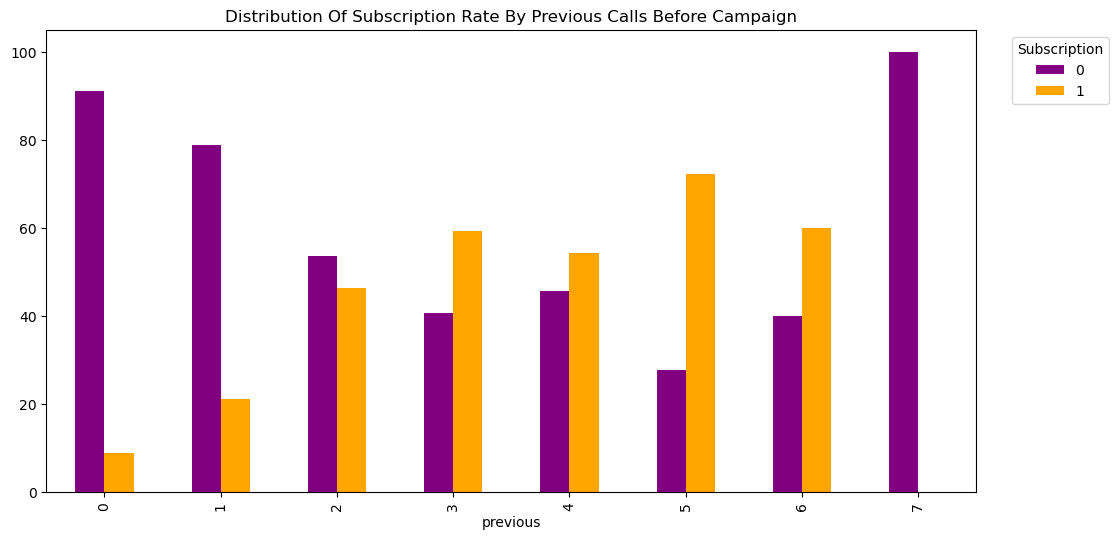

In [81]:
pcam.plot(kind='bar', figsize=[12,6], color=['purple', 'orange'])
plt.title("Distribution Of Subscription Rate By Previous Calls Before Campaign")
plt.legend(title='Subscription', bbox_to_anchor=(1.15,1.0))
plt.show()

### Clients with more prior contacts initially show a higher likelihood of subscribing, indicating that repeated engagement increases conversion chances.

### However, beyond five prior contacts, the subscription rate begins to decline, suggesting that excessive contact may reduce the likelihood of conversion, as clients may become less responsive or more resistant after multiple attempts.

# Temporal Analysis:

### Which months have higher subscription rates?

In [41]:
months = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

In [42]:
ms = df.groupby('month')['y'].value_counts(normalize=True).unstack() * 100
ms = ms.reindex(months)
ms

y,0,1
month,,
mar,49.450549,50.549451
apr,79.521277,20.478723
may,93.565255,6.434745
jun,89.488530,10.511470
jul,90.953443,9.046557
aug,89.397863,10.602137
sep,55.087719,44.912281
oct,56.128134,43.871866
nov,89.856133,10.143867


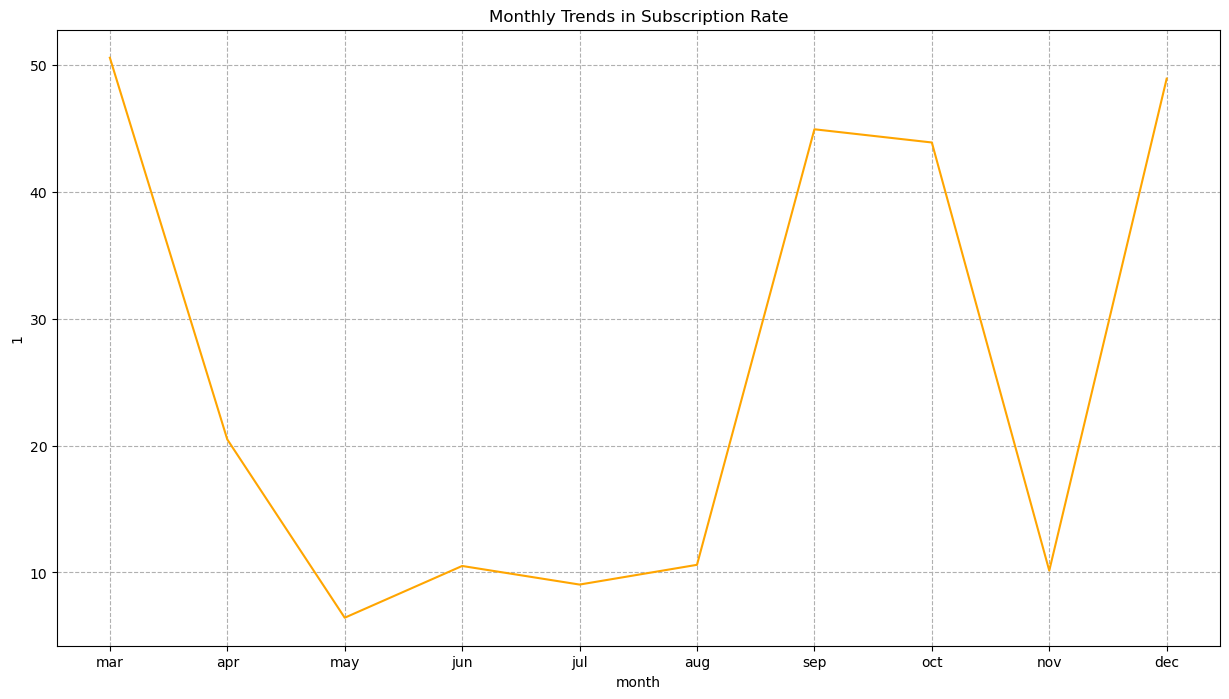

In [82]:
plt.figure(figsize=[15,8])
sb.lineplot(x=ms.index, y=ms[1], color='orange')
plt.title("Monthly Trends in Subscription Rate")
plt.grid(linestyle='--')
plt.show()

### The subscription rate is highest in March, indicating that most clients were converted into subscribers during this month compared to other months. 
### Following March, there is a noticeable decline in the subscription rate, suggesting a lower client conversion rate in the subsequent months.
### Especially in May as it shows the lowest subscription rate around 4-5%.
### After August, the subscription rate begins to rise again, remaining relatively stable from August to October, before dropping to around 10% in November. 
### Following November, the subscription rate increases again, reaching slightly below 50%.

### Is there any effect of the day of the week on subscription success?

In [44]:
days = ['mon', 'tue', 'wed', 'thu', 'fri']

In [45]:
dws = df.groupby('day_of_week')['y'].value_counts(normalize=True).unstack() * 100
dws = dws.reindex(days)
dws

y,0,1
day_of_week,,
mon,90.051680,9.948320
tue,88.220025,11.779975
wed,88.332924,11.667076
thu,87.881248,12.118752
fri,89.191261,10.808739


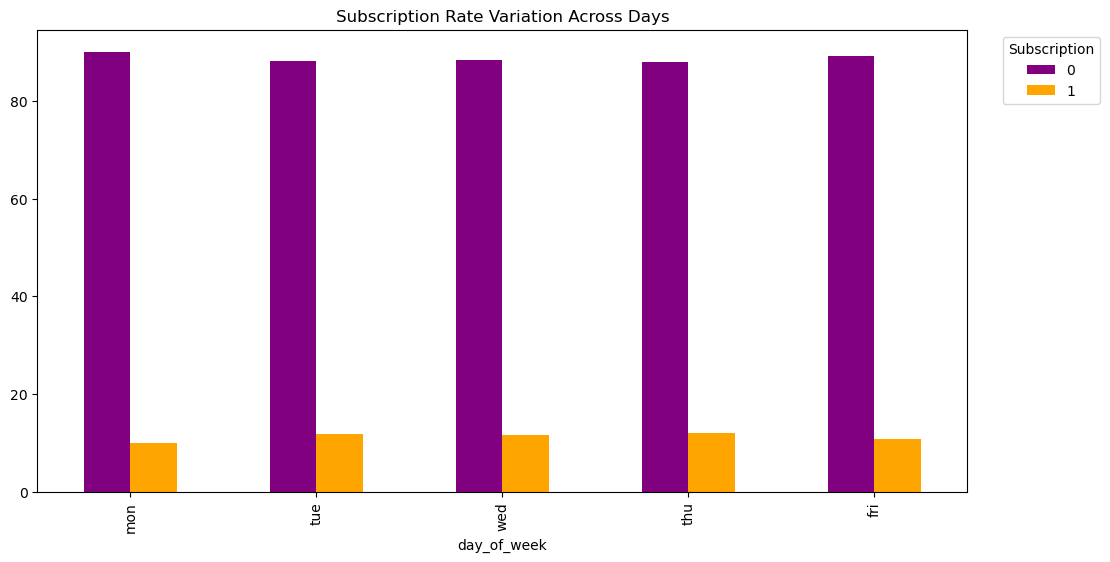

In [83]:
dws.plot(kind='bar', figsize=[12,6], color=['purple', 'orange'])
plt.title("Subscription Rate Variation Across Days")
plt.legend(title='Subscription', bbox_to_anchor=(1.15,1.0))
plt.show()

### Subscription rates peak on Thursdays (12%) and are lowest on Mondays (9–10%), likely reflecting higher customer engagement midweek and lower responsiveness at the start of the week.